# TS1: Síntesis y operaciones de señales
### Gonzalo Constenla

[Nbviewer](https://nbviewer.org/github/GConstenlaP/AyPS/blob/main/TS1/TS1.ipynb)

El objetivo es analizar las distintas señales propuestas; señales sinusoidales variando su amplitud (de distinta potencia), luego señales estocásticas; ruido de distribucion normal y de distribucion uniforme y luego una señal de pulso cuadrado. Luego observar y estudiar los cambios en la transformada de Fourier de estas señales.

### Marco Teórico
#### La transformada de Fourier
La transformada discreta de Fourier permite representar una señal discreta $ x[n] $ De N muestras en el dominio de la frecuencia, descomponiendola en las N frecuencias $ k $ presentes en la señal según la fórmula:

$$
X[k] = \sum_{n=0}^{N-1} x[n]e^{-j\frac{2\pi}{N}kn},
\qquad k=0,1,\ldots,N-1
$$


En la cual, $X[k]$ es un numero complejo con magnitud y fase que representa la contribucion de la frecuencia $k$. Se puede interpretar como un vector: $X[k] = Re{X[k]} + j·Im{X[k]}$, donde $Re{X[k]}$ es parte real e $ Im{X[k]}$ la parte imaginaria. Por lo cual tomamos el módulo:
$$
|X[k]| = \sqrt{\operatorname{Re}\{X[k]\}^2 + \operatorname{Im}\{X[k]\}^2}
$$
el cual que nos permite analizar la amplitud de cada frecuencia.
En este trabajo se utiliza la transformada rapida de Fourier  (FFT), un algoritmo eficiente para calcular la DFT.



#### La Energia
La energia de las N muestras de una señal discreta se define:

$$
E =
\sum_{n=0}^{N-1}
|x[n]|^2
$$

#### Potencia media
Se define como el promedio de X^2:


$$P_{\text{media}}
=
\frac{1}{N}
\sum_{n=0}^{N-1}
|x[n]|^2$$

Por lo tanto:

$$
\boxed{
P_{\text{media}} = \frac{E}{N}
}
$$

#### Varianza
La varianza mide la dispersión de los valores de una variable aleatoria
respecto de su valor medio:

$$
Var⁡(X) = \sigma^2 = E[X^2] - \mu^2
$$

donde μ representa la esperanza matemática, también llamada valor esperado.
$$
\mu = E[X]
$$


#### Parseval
Luego, tambien para señales discretas, el teorema de Parseval establece la conservación de energía entre dominios temporal y frecuencial, según:

$$
\sum_{n=0}^{N-1}
|x[n]|^2
=
\frac{1}{N}
\sum_{k=0}^{N-1}
|X[k]|^2$$

Por lo tanto, la potencia media también puede calcularse a partir de la DFT:

$$
\boxed{
P_{\text{media}}
=
\frac{1}{N}
\sum_{n=0}^{N-1}
|x[n]|^2
=
\frac{1}{N^2}
\sum_{k=0}^{N-1}
|X[k]|^2
}
$$



### DESARROLLO

Importo librerias a utilizar y defino algunos parametros:

In [27]:

import numpy as np
import matplotlib.pyplot as plt
import scipy

N = 1000
f0 = 2000
fs = 20000
n = np.arange(N)
t = n / fs

delta_f = fs / N  # resolución espectral en hz = 20




#### SEÑAL 1
Para la señal 1 se pide: Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
La expresion matematica a utilizar para generar la señal sinusoidal discreta es: $$
x[n] = A\sin(\omega_0 n + \phi)
$$


Por lo tanto defino: fs,  frecuencia de muestreo = 20000, tal que haya al menos 10 muestras por periodo según la siguiente inecuacion: $f_s \geq 10 \cdot f_0$

Para esta señal se utilizaron N = 1000 muestras. 

Genero la SEÑAL 1: Señal sinusoidal de 1 Watt. La grafico en t, tiempo total de muestreo y en T, un ciclo de señal.

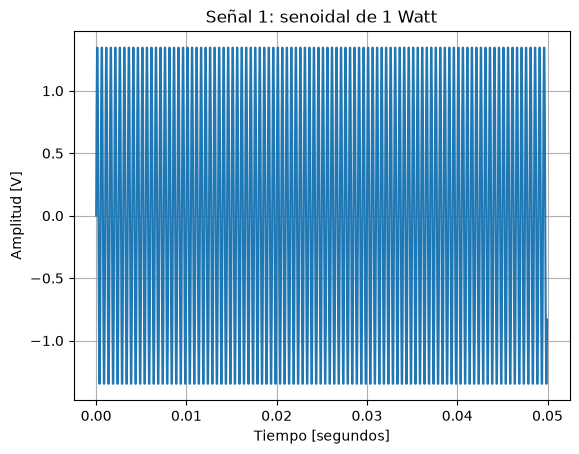

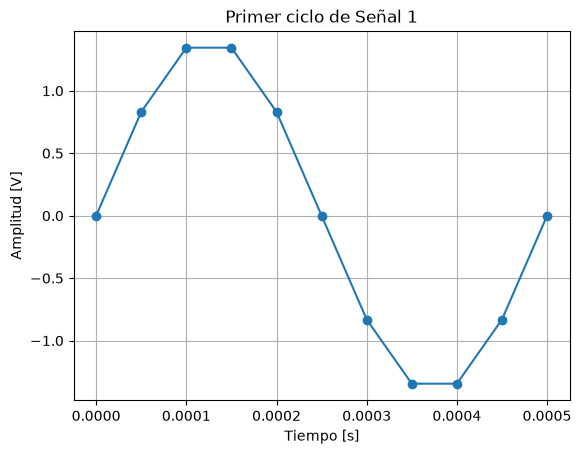

In [4]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    tt = np.arange(nn) / fs

    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx


def graficar_primer_ciclo(t, x, f, titulo):
    muestras_por_ciclo = int(fs / f)

    plt.figure()
    plt.plot(t[:muestras_por_ciclo + 1], x[:muestras_por_ciclo + 1],'o-')
    plt.title(titulo)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.grid()
    plt.show()

A1 = np.sqrt(2)

tt, xx = mi_funcion_sen(vmax=A1, dc=0, ff=f0, ph=0, nn=N, fs=fs)

plt.figure(1)
plt.plot(tt, xx)
plt.title('Señal 1: senoidal de 1 Watt')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

graficar_primer_ciclo(tt, xx, f0, 'Primer ciclo de Señal 1')

Y su transformada:

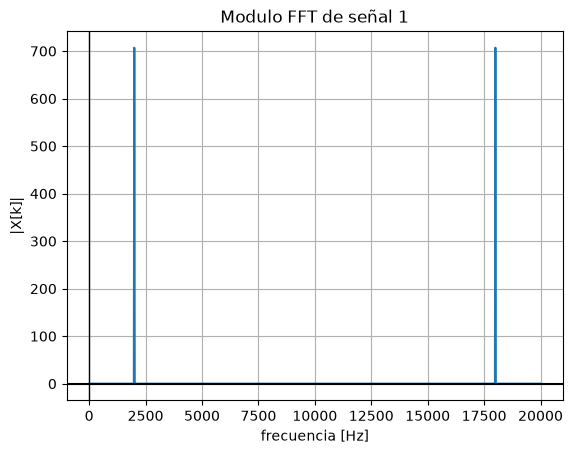

In [7]:
fft_1= scipy.fft.fft(xx)

modulo_1 = np.abs(fft_1)

frecuencias = np.arange(N) * delta_f

#

plt.figure(2)
plt.plot(frecuencias,modulo_1)
plt.title("Modulo FFT de señal 1")
plt.ylabel("|X[k]|")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

El espectro presenta 2 picos, el primero se encuentra en 2000hz y coincide con el valor esperado ya que la señal fue generada con una frecuencia de 2000hz, por lo que el contenido espectral se concentra en esa frecuencia.

Luego aparece otro pico en 18000hz, que representa la componente de frecuencia negativa −2000 Hz.
Este pico aparece porque las señales sinusoidales pueden expresarse de forma exponencial compleja según la expresión:
$$
\sin(\omega_0 n) = \frac{e^{j\omega_0 n} - e^{-j\omega_0 n}}{2j}
$$
De esta expresion se observa que una sinusoidal tiene componentes en las frecuencias f0 y -f0, de acá: la frecuencia -f0 = -2000hz.

Luego, además, la DFT es periodica con periódo fs, en esta caso fs = 20khz. Por lo que X(f) = X(f + fs). Y en concreto: X(f0=2000hz) = X(2000hz+20000hz). Y para la componente negativa tambien: X(-2000hz) = X(-2000hz + 20000hz)



### Módulo normalizado de transformada de SEÑAL 1 (Gráfico de Mayor interés)
Sin embargo, este gráfico no esta normalizado, por ello adjuntare el gráfico de los valores absolutos normalizado por N muestras para esta y las siguientes señales: $|X[k]|/N$ , para poder interpretar y comparar magnitudes en una escala, donde se puedan apreciar los cambios eliminando la dependencia del numero de muestras N en el valor de la DFT. 

Además imprimo los valores exactos del modulo normalizado de la FFT conociendo los índices K de los BINS de las frecuencias 2khz y 18khz.

La resolución espectral es Δf = Fs/N = 20 Hz y es la separación en frecuencia entre cada BIN con el siguiente.

Por lo tanto: los indices son K = 100 para la frecuencia de 2000hz ya que 100 · 20 = 2000 Hz.

Y K = 900 para la frecuencia de 18000hz



Modulo de la transformada en el bin 100: X[100]: 0.7071067811865478 
Modulo de la transformada en el bin 900: X[900]: 0.7071067811865478


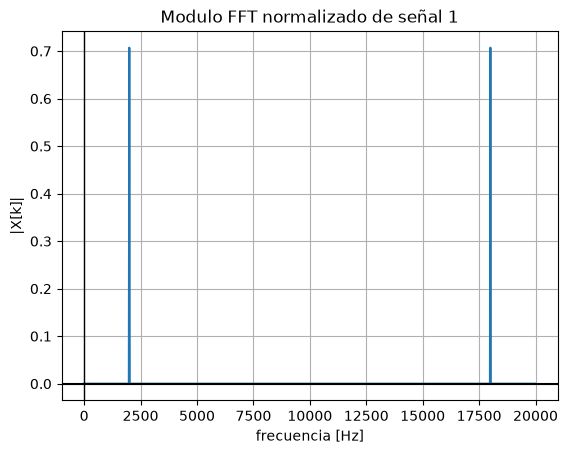

In [12]:
modulo_1_norm =  modulo_1/N

plt.figure(100)
plt.plot(frecuencias,modulo_1_norm)
plt.title("Modulo FFT normalizado de señal 1")
plt.ylabel("|X[k]|")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

print("Modulo de la transformada en el bin 100: X[100]:", modulo_1_norm[100],"\nModulo de la transformada en el bin 900: X[900]:", modulo_1_norm[900])


Aca se pueden ver las 2 componentes del espectro que presentan un modulo normalizado de: A/2 = √2/2 ≈ 0,707. Valores en los que esta repartida la amplitud total de la señal (A) = √2.

Y recordando la expresión de la potencia de una sinusoidal: P = A²/2, para A = √2 obtenemos P = 1W. Este mismo valor de potencia puede obtenerse equivalentemente teniendo en cuenta la contribucion de las componentes en el dominio frecuencial segun: P ≈ 0,707² + 0,707² ≈ 1W
Entonces se puede concluir que la suma de cada componente de frecuencia con amplitud, permite obtener la amplitud original y que resulta coherente con la potencia media con la que fue generada la señal.



### SEÑAL 2:
Aca se utiliza la misma funcion para generar la funcion, cambiando el parametro de la amplitud, tal que la potencia sea de 2 Watts. Y la fase: φ = π/2

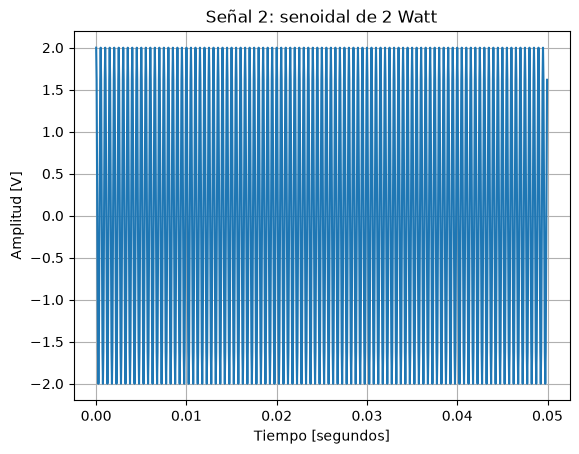

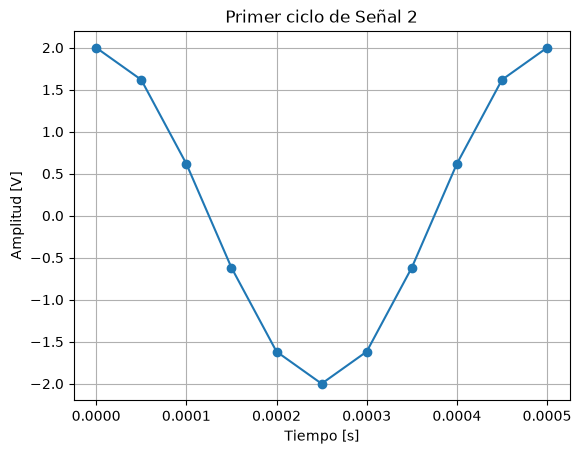

In [11]:
A2 = np.sqrt(2*2)

tt2, xx2 = mi_funcion_sen(vmax=A2, dc=0, ff=f0,ph=np.pi/2, nn=N, fs=fs)

plt.figure(3)
plt.plot(tt2, xx2)
plt.title('Señal 2: senoidal de 2 Watt')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

graficar_primer_ciclo(tt2, xx2, f0, 'Primer ciclo de Señal 2')

Ademas del cambio evidente en la fase se observa el cambio generado en la amplitud. Y como la potencia media de una sinusoidal es proporcional al cuadrado de su amplitud segun la expresión:
$$
P = \frac{A^2}{2}
$$
Aumentar la amplitud, aumenta la potencia.

A continuación se presenta directamente el gráfico del módulo normalizado.


Modulo de la transformada en el bin 100: X[100]: 0.9999999999999998 
Modulo de la transformada en el bin 900: X[900]: 0.9999999999999998


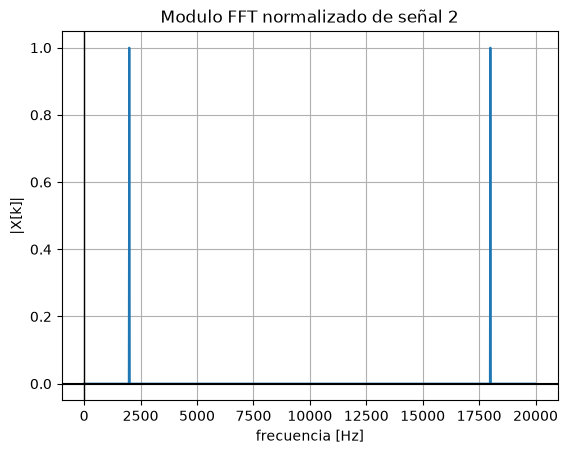

In [15]:
fft_2= scipy.fft.fft(xx2)

modulo_2 = np.abs(fft_2)

frecuencias2 = np.arange(N) * delta_f

modulo_2_norm =  modulo_2/N

plt.figure(100)
plt.plot(frecuencias,modulo_2_norm)
plt.title("Modulo FFT normalizado de señal 2")
plt.ylabel("|X[k]|")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
print("Modulo de la transformada en el bin 100: X[100]:", modulo_2_norm[100],"\nModulo de la transformada en el bin 900: X[900]:", modulo_2_norm[900])



Aca se puede ver que el cambio de la potencia no tuvo influencia en la frecuencia donde figuran los picos, pero según lo esperado si se ve un cambio en la magnitud y los picos de la FFT aumentan.
Como la frecuencia no cambió, el espectro tiene picos exactamente en los mismos lugares: 2000hz y 18000hz.
Tambien vemos que el desfase no tiene influencia sobre los picos.

Y esta vez tenemos en cada pico una amplitud A/2 = 0.999999999 ≈ 1. 

Por lo tanto la potencia de la señal 2 es: P = 1² + 1² = 2W

### COMPARACION DE FASE ENTRE SEÑAL 1 y SEÑAL 2:
La fase $\phi$ de un numero complejo se obtiene segun: $\phi = \arctan\left(\frac{\operatorname{Im}(X)}{\operatorname{Re}(X)}\right)
$

Y si graficamos la fase de la FFT de señal 1 y señal 2 se puede ver el desfase. Aca de se debe tener en cuenta que la fase donde |X[k]| ≈ 0, no tiene relevancia y se realiza el analisis solo sobre los deltas. 

Esto se debe a que en las frecuencias donde no hay señal, la fft sigue devolviendo valores complejos de ordenes muy pequeños por error de imprecision de calculo computacional, por lo tanto, esta operacion devuelve valores aleatorios sin sentido.

Para evitar esto se puede se puede usar un algoritmo que implementa un umbral que deba ser superado por el modulo de la fft y analizar la fase solo en las frecuencias superadores de dicho umbral., En este caso, este paso no es necesario porque ya se conocen las frecuencias en las que el espectro esta concentrado.

Entonces con las frecuencias conocidas, obtenemos los indices K de los bins en los cuales calculamos la fase y la graficamos:

K = 100 para frecuencia de 2000 Hz
Y K = 900 para la frecuencia de 18000 Hz



SEÑAL 1
Fase en 2000 Hz: -1.570796326794928 rad
Fase en 18000 Hz: 1.570796326794928 rad

SEÑAL 2
Fase en 2000 Hz: -2.6785036754767917e-14 rad
Fase en 18000 Hz: 2.6785036754767917e-14 rad


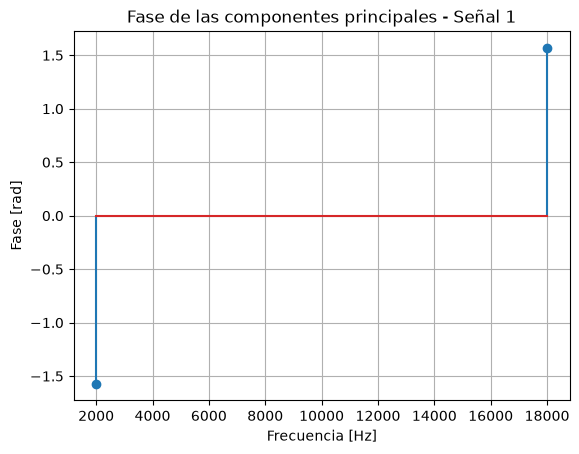

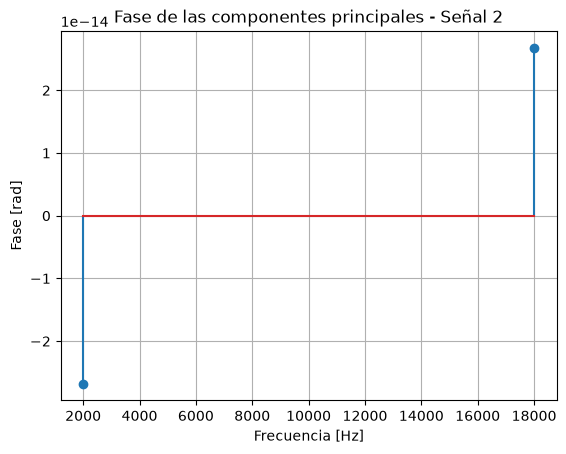

In [22]:
#%% diferencia de fase entre señal 1 y 2

#1 fase de numero complejo: φ = atan2(Im(X[k]), Re(X[k]))

fase_1 = np.angle(fft_1)
fase_2 = np.angle(fft_2)

print("SEÑAL 1")
print("Fase en 2000 Hz:", fase_1[100], "rad") #-π/2 rad
print("Fase en 18000 Hz:", fase_1[900], "rad") #+π/2 rad
print("\nSEÑAL 2")
print("Fase en 2000 Hz:", fase_2[100], "rad")
print("Fase en 18000 Hz:", fase_2[900], "rad")

frecuencias_fase = [2000, 18000]
fase_1i = [fase_1[100], fase_1[900]]
fase_2i = [fase_2[100], fase_2[900]]

plt.figure()
plt.stem(frecuencias_fase, fase_1i)
plt.title("Fase de las componentes principales - Señal 1")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.grid()
plt.show()

plt.figure()
plt.stem(frecuencias_fase, fase_2i)
plt.title("Fase de las componentes principales - Señal 2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.grid()
plt.show()



#### El programa devolvio para la SEÑAL 1:

Fase en 2000 Hz: -1.570796326794928 rad ≈ −π/2 rad

Fase en 18000hz: 1.570796326794928 rad ≈ π/2 rad

En la frecuencia de 2000hz, la fase es de −π/2 rad, entonces como sabemos que 18000hz equivale a -2000hz, sabemos por simetria conjugada de la señal real, que la fase en 18000hz debe ser +π/2 rad.



#### Y el programa devolvio para la SEÑAL 2:

Fase en 2000 Hz: -2.6785036754767917e-14 rad, valor muy cercano al 0

Fase en 18000hz: 2.6785036754767917e-14 rad, valor muy cercano al 0

A pesar de que la gráfica es similar, la escala es muy pequeña, por lo que se deduce que el valor de la fase calculado es muy cercano al 0 y se trata de un error de calculo computacional y entonces interpretamos fase = 0.

Para averiguar si la fase obtenida corresponde a algun error de calculo computacional, podemos calcular el valor complejo de la transformada.

Y asi obtenemos:

X(100) ≈ 1 - 0i

X(900) ≈ 1 + 0i.

Ambos numeros complejos, con parte imaginaria aproximando a 0 (2.6785036754767914e-14j), por lo que interpretamos ambos numeros, con parte imaginaria = 0, puramente reales y entonces fase = 0.


Ademas hacer la resta de las fases en ambas señales para ver el desfase, y efectivamente obtenemos 1.5707963267949012 ≈ +π/2 rad




In [25]:

print(fft_2[100]/N)
print(fft_2[900]/N)
print("Diferencia de fase entre las señales:", fase_2[100] - fase_1[100])

(0.9999999999999998-2.6785036754767914e-14j)
(0.9999999999999998+2.6785036754767914e-14j)
Diferencia de fase entre las señales: 1.5707963267949012


### SEÑAL 3: Ruido normal
Genero la Señal de ruido de distribucion normal con valor medio = μ = E[X] = 0V  y varianza = 0.1 W. 
Grafico de Señal y Gráfico de modulo de transformada de la señal normalizado por N

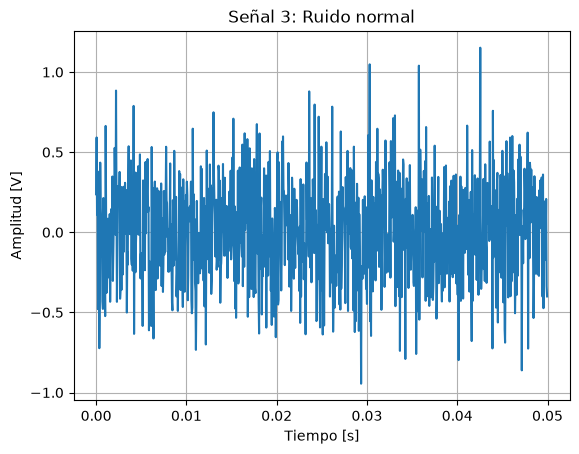

Modulo de la transformada en el bin 100: X[100]: 0.013344196073966365 
Modulo de la transformada en el bin 900: X[900]: 0.013344196073966365


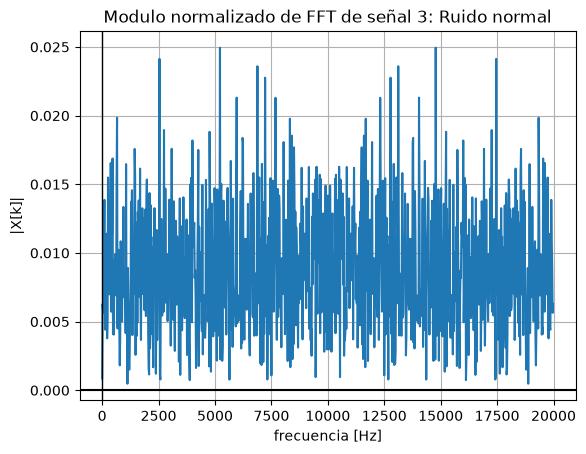

In [61]:
def gen_noise_normal(media=0, varianza=0.1, nn=N):

    desv_est = np.sqrt(varianza)

    ruido_normal = np.random.normal(media, desv_est, nn)

    return ruido_normal


ruido_normal = gen_noise_normal()

plt.figure(5)
plt.plot(t, ruido_normal)
plt.title("Señal 3: Ruido normal")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

fft_ruido_normal = scipy.fft.fft(ruido_normal)

modulo_ruido_normal = np.abs(fft_ruido_normal)

modulo_ruido_normal_normalizado =  modulo_ruido_normal/N

plt.figure()
plt.plot(frecuencias,modulo_ruido_normal_normalizado)
plt.title("Modulo normalizado de FFT de señal 3: Ruido normal")
plt.ylabel("|X[k]|")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

print("Modulo de la transformada en el bin 100: X[100]:", modulo_ruido_normal_normalizado[100],"\nModulo de la transformada en el bin 900: X[900]:", modulo_ruido_normal_normalizado[900])



A diferencia de las señales anteriores, el Ruido no posee una unica frecuencia definida, las frecuencias presentes en la señal se distribuyen a lo largo del espectro en distintas magnitudes(amplitud/modulo). Tambien se puede observar la simetria conjugada a partir de fs/2 = 10000hz, valor en frecuencia donde se encuentra el eje de simetría del espectro.

Vemos que Ya no tiene sentido calcular el modulo de la transformada en indices de frecuencias especfiicas, ya que la amplitud esta distribuida a los largo de todas las frecuencias presentes en el ruido.

### SEÑAL 4: Ruido uniforme
Genero la Señal de ruido de distribucion uniforme con valor medio = μ = E[X] = 0V y varianza = 0.1 W.

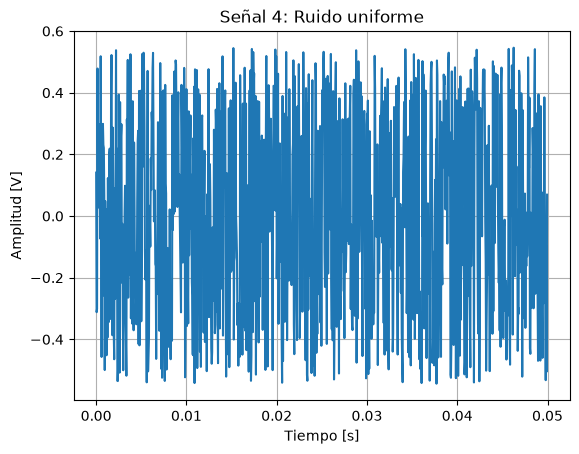

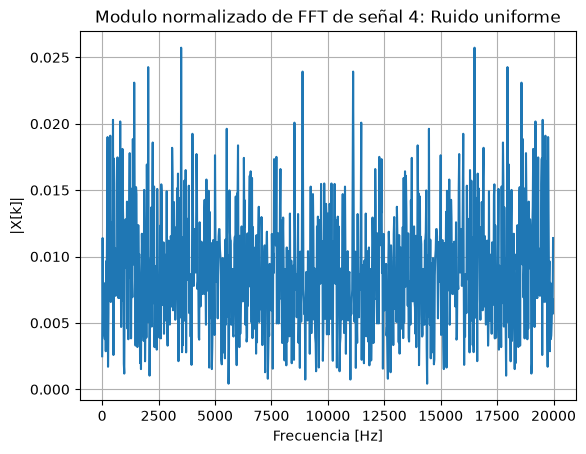

In [59]:

def gen_noise_uniforme(varianza=0.1, nn=N):

    a = np.sqrt(3 * varianza)

    ruido_uniforme = np.random.uniform(-a, a, nn)

    return ruido_uniforme
ruido_uniforme = gen_noise_uniforme(varianza=0.1)

plt.figure(7)
plt.plot(t, ruido_uniforme)
plt.title("Señal 4: Ruido uniforme")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()


fft_ruido_uniforme = scipy.fft.fft(ruido_uniforme)

modulo_ruido_uniforme = np.abs(fft_ruido_uniforme)
modulo_ruido_uniforme_normalizado =  modulo_ruido_uniforme/N


plt.figure(8)
plt.plot(frecuencias, modulo_ruido_uniforme_normalizado)
plt.title("Modulo normalizado de FFT de señal 4: Ruido uniforme")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()




Se puede ver que en el espectro de Ruido Uniforme al igual que en el espectro del ruido Normal, no hay frecuencias claramente dominantes, sino que, estas están distribuidas a lo largo de todo el rango: [0, 20k]hz ya que son señales generadas aleatoriamente.


### Potencia media De señales de ruido normal y ruido uniforme
Comparacion del calculo de potencia por el teorema de Parseval: en ambos dominios la potencia obtenida deberia ser equivalente.

En el dominio temporal: $$P_{\text{media}}
=
\frac{1}{N}
\sum_{n=0}^{N-1}
|x[n]|^2$$

Y en el dominio frecuencial

$$
\
P_{\text{media}}
=
\frac{1}{N^2}
\sum_{k=0}^{N-1}
|X[k]|^2
$$

Luego usando el valor medio muestral (que difiere del teorico $E[X] = μ = 0V$) para obtener la varianza experimental $Var⁡(X) = \sigma^2 = E[X^2] - \mu^2$ y compararla con la teorica: $Var⁡(X) = \sigma^2 =  0.1 W$





In [64]:
#SEÑAL RUIDO NORMAL

print("RUIDO NORMAL")
print("PARSEVAL:")

P_ruido_normal = np.sum(ruido_normal**2) / N
print("Potencia media de Ruido normal en el dominio temporal:", P_ruido_normal)

#Chequeo Parseval, me deberia dar la misma potencia media
P_ruido_normal_fft = np.sum(np.abs(fft_ruido_normal)**2) / N**2

print("Potencia media del Ruido normal en el dominio frecuencial:", P_ruido_normal_fft)

# Valor medio muestral E[X] = μ
mu_normal = np.mean(ruido_normal)

# Varianza mediante la formula: Var(X) = E[X²] - μ²
var_normal_formula = P_ruido_normal - (mu_normal**2)

print("\nValor medio (μ):", mu_normal )
print("Varianza mediante la formula:", var_normal_formula)


#
#
#SEÑAL RUIDO UNIFORME
print("\nRUIDO UNIFORME")
print("PARSEVAL:")

P_ruido_uniforme = np.sum(ruido_uniforme**2) / N
print("Potencia media de Ruido uniforme en el dominio temporal:", P_ruido_uniforme)

#Chequeo Parseval, me deberia dar la misma potencia media
P_ruido_uniforme_fft = np.sum(np.abs(fft_ruido_uniforme)**2) / N**2

print("Potencia media del Ruido Uniforme en el dominio frecuencial:", P_ruido_uniforme_fft)

# Valor medio muestral E[X] = μ
mu_uniforme = np.mean(ruido_uniforme)

# Varianza mediante la formula: Var(X) = E[X²] - μ²
var_uniforme_formula = P_ruido_uniforme - (mu_uniforme**2)

print("\nValor medio (μ):", mu_uniforme )
print("Varianza mediante la formula:", var_uniforme_formula)


RUIDO NORMAL
PARSEVAL:
Potencia media de Ruido normal en el dominio temporal: 0.09734180613582606
Potencia media del Ruido normal en el dominio frecuencial: 0.09734180613582608

Valor medio (μ): 0.0008616412782451847
Varianza mediante la formula: 0.09734106371013368

RUIDO UNIFORME
PARSEVAL:
Potencia media de Ruido uniforme en el dominio temporal: 0.10052646815080966
Potencia media del Ruido Uniforme en el dominio frecuencial: 0.10052646815080966

Valor medio (μ): -0.0024899725835085588
Varianza mediante la formula: 0.10052026818734304


#### Parseval
Analizando los resultados, vemos que efectivamente se cumple Parseval y se obtiene el mismo valor de potencia media para ambas señales de ruido tanto en dominio frecuencial como temporal

#### Variazna Experimental
Luego vemos que la varianza experimental del ruido normal obtenida 0.10494429469088637 resulta cercana a la teorica 0,1.

Igual que con la varianza experimental del ruido uniforme 0.10052026818734304.

#### μ
Lo mismo con el valor medio muestral ruido normal (μ): 0.00086 vs el teorico (μ): 0.0

Y valor medio muestral ruido uniforme (μ): -0.0024899725835085588 vs el teorico (μ): 0.0

#### Conclusion 
Se observa una ligera diferencia entre los valores teoricos y los experimentales, debido a que se trata de una realizacion de un experimento aleatorio con finitas muestras, Y lo esperable es que a mayor numero de muestras, mas cercano sea el valor experimental del teorico.



### SEÑAL 5: Pulso Rectangular
Genero una señal de Pulso Rectangular con misma frecuencia, de potencia = 1 Watt y Ciclo de Actividad = 0.5


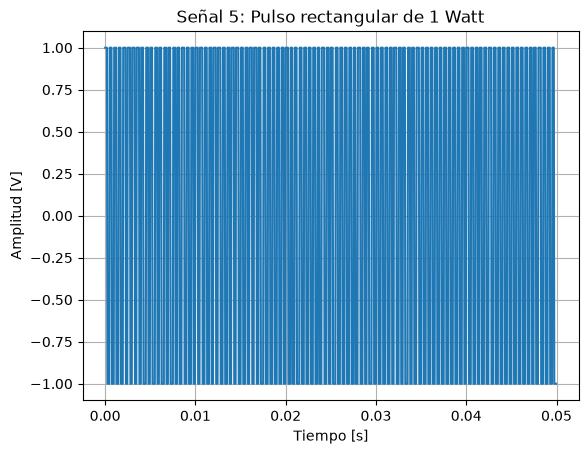

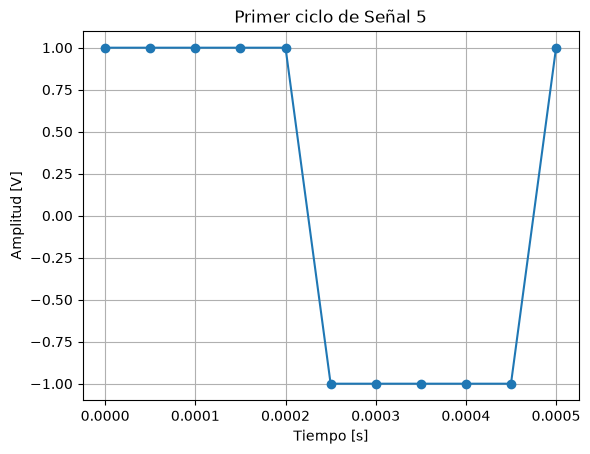

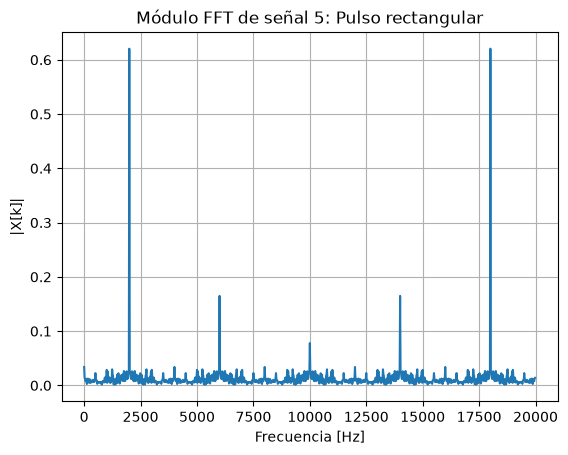

In [65]:
def mi_funcion_pulso_rectangular(vmax=1, ff=1, duty=0.5, nn=N, fs=fs):

    tt = np.arange(nn) / fs

    xx = vmax * scipy.signal.square(2 * np.pi * ff * tt, duty=duty)

    return tt, xx

    
A5 = 1
duty5 = 0.5


tt5, xx5 = mi_funcion_pulso_rectangular(vmax=A5, ff=f0, duty=duty5, nn=N, fs=fs)

plt.figure(9)
plt.plot(tt5, xx5)
plt.title("Señal 5: Pulso rectangular de 1 Watt")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

graficar_primer_ciclo(tt5, xx5, f0, 'Primer ciclo de Señal 5')

# Transformada de señal 5
fft_5 = scipy.fft.fft(xx5)

modulo_5 = np.abs(fft_5)
modulo_5_norm =  modulo_5/N

plt.figure(10)
plt.plot(frecuencias, modulo_5_norm)
plt.title("Módulo FFT de señal 5: Pulso rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|X[k]|")
plt.grid()
plt.show()

Aca se observan los picos principales en las mismas frecuencias de 2000hz y 18000 hz (la frecuencia fundamental), pero ademas aparecen otros picos en 6khz y 14khz que corresponden a los armonicos. Esto ocurre porque una señal cuadrada o rectangular está respresentada por mas de una senoidal, por lo tanto hay varias frecuencias presentes en la señal original que se pueden visualizar en el espectro frecuencial generado con la fft.
Tambien se observa que la amplitud de los armonicos va disminuyendo a medida que aumenta el numero de armonico. La disminucion aproximada de la amplitud de los armonicos es proporcional a 1/n, n el numero del armonico.
En conclusion el Espectro de la FFT permite visualizar mas de una frecuencia presente en la señal original, con la fundamental, la de mayor amplitud.

